In [9]:
##Import libraries
import pandas as pd
from affine import Affine
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import folium
import math
import time
import sys
import geopy
import numpy as np
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster, PolyLineTextPath
from shapely.geometry import MultiPolygon
from shapely.ops import split, unary_union
from statistics import mean,median
from pykrige.ok import OrdinaryKriging
from matplotlib import cm, colors
from io import BytesIO
import base64
from PIL import Image
from rasterio.features import rasterize
from affine import Affine
import rasterio
from rasterio import features
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from geovoronoi import voronoi_regions_from_coords, points_to_coords
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Polygon, box, shape
from sklearn.metrics import pairwise as skm
import libpysal
import spopt

print("Import complete")

Import complete


Index(['R', 'delta_R', 'R_sig', 'L', 'delta_L', 'L_sig', 'B95', 'ref_dec',
       'dec', 'ref_inc', 'ref_mean_N', 'ref_mean_K', 'ID', 'loc', 'name',
       'Rock type', 'AgeMeth', 'MagMin', 'Primary', 'FieldTest', 'MaxAgeMag',
       'MinAgeMag', 'Nsites', 'mdec', 'minc', 'a95', 'k', 'K', 'BedStrike',
       'BedDip', 'Plat', 'Plon', 'Lambda', 'Ref', 'DOI', 'Comments',
       'Collection', 'Notes', 'Polarity', 'agehigh', 'agelow', 'period',
       'N_alt', 'lambda', 'slon', 'age', 'N', 'min_age', 'max_age', 'slat',
       'plon', 'A95', 'plat'],
      dtype='str')


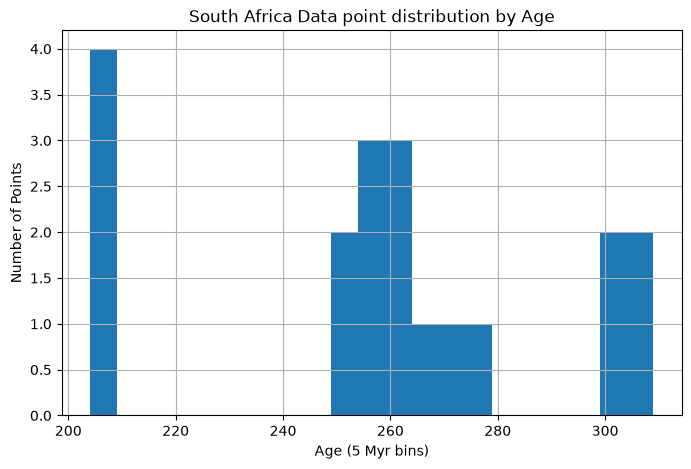

In [10]:
#TEMPORARY STRUCTURE  JUST TO MAKE SURE THE WHOLE PIPELINE WORKS

rot_data=pd.read_csv(r"C:\Users\Usuario\Documents\PMAGpythonRotation\results\results.csv")
tec_data=pd.read_csv(r"C:\Users\Usuario\Documents\PMAGpythonRotation\temp_tec.csv")

tec_data_renamed = tec_data.add_suffix("_tec")
rot_data_renamed = rot_data.add_suffix("_rot")

merged = pd.concat([rot_data_renamed, tec_data_renamed], axis=1)

overlap_cols = set(tec_data.columns) & set(rot_data.columns)
overlap_cols.discard("name")

for col in overlap_cols:
    merged[col] = merged[f"{col}_tec"].combine_first(merged[f"{col}_rot"])
    merged.drop([f"{col}_tec", f"{col}_rot"], axis=1, inplace=True)

#merged_data=merged[["Island","name","N","age","min_age","max_age", "mdec","minc","a95","k","R","delta_R","R_sig","A95","B95","K",
 #            "plat","plon","lambda","L","delta_L", "L_sig",
 #            "ref_dec","ref_inc","ref_mean_N","ref_mean_K","period","slat","slon","Ref","Notes"]]
merged.columns = merged.columns.str.replace(r'(_rot|_tec)$', '', regex=True)
print(merged.columns)

def rot_sense(df):
    df["rot_sense"]=""
    for idx, row in df.iterrows():
        if row["R_sig"] and row["R"] > 0:
            df.loc[idx, "rot_sense"] = "CW"
        elif row["R_sig"] and row["R"]<0:
            df.loc[idx, "rot_sense"] = "CCW"
        else:
            df.loc[idx, "rot_sense"] = ""
    return df

data=rot_sense(merged)

bins = np.arange(data["age"].min(), data["age"].max() + 5, 5)

plt.figure(figsize=(8,5))
plt.hist(data["age"], bins=bins)

plt.xlabel("Age (5 Myr bins)")
plt.ylabel("Number of Points")
plt.title("South Africa Data point distribution by Age")
plt.grid(True)

plt.show()

In [12]:
#Variogram model choice
variogram_model = 'spherical' 

filtered_data = data[(data["age"] >= 0) & (data["age"] <= 330)]

print(len(filtered_data))

rads = np.deg2rad(filtered_data['R'].values)

filtered_data['cos'] = np.cos(rads)
filtered_data['sin'] = np.sin(rads)

X = filtered_data['slon'].values
Y = filtered_data['slat'].values
Zx = filtered_data['cos'].values
Zy = filtered_data['sin'].values

min_lat, max_lat = filtered_data['slat'].min(), filtered_data['slat'].max()
min_lon, max_lon = filtered_data['slon'].min(), filtered_data['slon'].max()
grid_lon = np.linspace(min_lon, max_lon, 1000)
grid_lat = np.linspace(min_lat, max_lat, 1000)

ok_x = OrdinaryKriging(X, Y, Zx,
                       variogram_model=variogram_model, verbose=False, enable_plotting=False)
zx_pred, zx_ss = ok_x.execute('grid', grid_lon, grid_lat)

ok_y = OrdinaryKriging(X, Y, Zy,
                       variogram_model=variogram_model, verbose=False, enable_plotting=False)
zy_pred, zy_ss = ok_y.execute('grid', grid_lon, grid_lat)

# zx_pred and zy_pred are 2D arrays on the grid
# Normalize vector length to avoid numerical issues
magnitude = np.sqrt(zx_pred**2 + zy_pred**2)
# avoid divide by zero
magnitude[magnitude == 0] = 1.0
nx = zx_pred / magnitude
ny = zy_pred / magnitude

# Convert back to angles (radians -> degrees, range -180..180)
theta_rad = np.arctan2(ny, nx)
theta_deg = np.rad2deg(theta_rad)

# Optionally convert to 0..360
theta_deg360 = (theta_deg + 360) % 360

print(theta_deg360.shape)

print(min_lat)
print(min_lon)

print(max_lat)
print(max_lon)


19


ValueError: zero-size array to reduction operation maximum which has no identity

In [13]:
world = gpd.read_file(r"C:\Users\rosso\Downloads\geoBoundariesCGAZ_ADM0\geoBoundariesCGAZ_ADM0.shp")
country = world[world['shapeName'] == "South Africa"]

lon_min = grid_lon.min()
lon_max = grid_lon.max()
lat_min = grid_lat.min()
lat_max = grid_lat.max()

lats = np.linspace(min_lat, max_lat, 1000)
lons = np.linspace(min_lon, max_lon, 1000)
lon_grid, lat_grid = np.meshgrid(lons, lats)

dlat = grid_lat[1] - grid_lat[0]
dlon = grid_lon[1] - grid_lon[0]

south = lats.min() - dlat / 2
north = lats.max() + dlat / 2
west  = lons.min() - dlon / 2
east  = lons.max() + dlon / 2

mask = features.geometry_mask(
  [mapping(country.geometry.values[0])],
    transform = rasterio.transform.from_bounds(
       west, south, east, north,
       width=1000, height=1000
                        ),
  invert=True,
  out_shape=lon_grid.shape
)

def create_geodataframe(df: pd.DataFrame) -> gpd.GeoDataFrame:
    geometry = gpd.points_from_xy(df['slon'], df['slat'])
    gdf = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")
    return gdf

gdf = create_geodataframe(filtered_data)

m = folium.Map(location=[north, west], tiles='cartodbpositron', zoom_start=5)

def add_direction_arrow(map_obj, lat, lon, dec_deg, rot_sense, dec, inc, a95, k, ref, length=1):
            #Calculate the end point of the arrow based on declination

            # compute direction vector (arrow length)
            angle_rad = np.deg2rad(dec_deg)
            dlat = length * np.cos(angle_rad)
            dlon = length * np.sin(angle_rad)

            start_lat = lat
            start_lon = lon
            end_lat = lat + dlat
            end_lon = lon + dlon
            
            end_lat = lat + dlat
            end_lon = lon + dlon
            if rot_sense=="CW":
                color="red"
            elif rot_sense=="CCW":
                color="blue"
            else:
                color="black"
            popup_html = f"""   <b>Dec:</b> {dec}<br>
                                <b>Inc:</b> {inc}<br>
                                <b>a95:</b> {a95}<br>
                                <b>k:</b> {k}<br>
                                <b>Lat:</b> {lat}<br>
                                <b>Lon:</b> {lon}<br>
                                <b>Reference:</b> {ref}"""
            line = folium.PolyLine(locations=[(start_lat, start_lon), (end_lat, end_lon)], 
                                   color=color, 
                                   opacity=0,
                                   popup=folium.Popup(popup_html, max_width=300)).add_to(map_obj)
            folium.CircleMarker(location=(lat, lon),
                                radius=10,
                                color=color,
                                fill=True,
                                fill_opacity=0,
                                opacity=0,
                                popup=folium.Popup(popup_html, max_width=300)
            ).add_to(map_obj)
            PolyLineTextPath(
                line,
                '➤',
                repeat=False,
                offset=0,
                attributes={'font-size': '20', 'fill': color}).add_to(map_obj)

for idx, row in gdf.iterrows():
                add_direction_arrow(
                    m, row["slat"], row["slon"], row["mdec"], row["rot_sense"], 
                    row["mdec"], row["minc"], row["a95"], row["k"], row["Ref"])

legend_html = """<div style='position: fixed; bottom: 50px; left: 50px; width: 180px; z-index:9999; font-size:14px;
                        background-color: white; border:2px solid grey; border-radius:8px; padding: 10px;'>
                        <b>Rotation Sense</b><br><i style='background:red;width:18px;height:18px;float:left;
                        margin-right:8px;opacity:0.8;display:inline-block;'></i>CW (Clockwise)<br>
                        <i style='background:blue;width:18px;height:18px;float:left;margin-right:8px;opacity:0.8;
                        display:inline-block;'></i>CCW (Counterclockwise)<br></div>"""

m.get_root().html.add_child(folium.Element(legend_html)) 
m.save("map_declination.html")

def add_rotation_overlay_to_map(m, lon_grid, lat_grid, theta_deg360, alpha=0.6):

    theta_rad = np.deg2rad(theta_deg360)
    cyclic_value = (1 - np.cos(theta_rad)) / 2  # smooth angular contrast
    
    norm = theta_deg360 / 360.0

    rgba_img = np.flipud(cm.get_cmap("hsv")(norm))
    rgba_img[..., -1] = alpha
    rgba_img[~mask, -1] = 0

    img = Image.fromarray((rgba_img * 255).astype(np.uint8))
    buffer = BytesIO()
    img.save(buffer, format="PNG")
    data_uri = "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("utf-8")

    # Add overlay
    overlay = folium.raster_layers.ImageOverlay(
        image=data_uri,
        bounds=[[south-0.4, west], [north-.04, east]],
        opacity=1.0,
        cross_origin=False,
        interactive=False
    )
    overlay.add_to(m)

    return m

coords = np.column_stack((gdf.geometry.x, gdf.geometry.y))

transform = rasterio.transform.from_bounds(
    west, south, east, north,
    width=mask.shape[1],
    height=mask.shape[0]
)

shapes = features.shapes(mask.astype(np.uint8), transform=transform)

mask_poly = unary_union([
    shape(geom) for geom, val in shapes if val == 1
])

vor = Voronoi(coords)

polygons = []

for region_idx in vor.point_region:
    region = vor.regions[region_idx]

    if not region or -1 in region:
        continue  # skip infinite regions

    poly = Polygon(vor.vertices[region])

    if poly.is_valid:
        polygons.append(poly)

clipped = []

for poly in polygons:
    inter = poly.intersection(mask_poly)
    if not inter.is_empty:
        clipped.append(inter)

vor_gdf = gpd.GeoDataFrame(geometry=clipped, crs="EPSG:4326")

joined = gpd.sjoin(
    gdf,
    vor_gdf,
    predicate="within"
)

poly_values = joined.groupby("index_right")["R"].mean()
vor_gdf["R"] = vor_gdf.index.map(poly_values)
vor_gdf["R"] = vor_gdf["R"].fillna(0)

def assign_rotation_clusters(vor_gdf, attribute, n_clusters):
      attrs_name = ["R"]
      vor_gdf["cluster"] = "None"

      spanning_forest_kwds = {
        "dissimilarity": skm.manhattan_distances,
        "affinity": None,
        "reduction": np.sum,
        "center": np.mean,
        "verbose": 2,
        }
      
      w = libpysal.weights.KNN.from_dataframe(vor_gdf, use_index=False, k=3)

      print(w.islands)

      model = spopt.region.Skater(
            vor_gdf,
            w,
            attrs_name,
            n_clusters=n_clusters,
            floor=1,
            trace=False,
            islands='drop',
            spanning_forest_kwds=spanning_forest_kwds,
        )
      model.solve()
      vor_gdf["cluster"] = model.labels_

assign_rotation_clusters(vor_gdf, "R", n_clusters=4)     

unique_labels = vor_gdf["cluster"].unique()

colormap = cm.get_cmap("tab10", len(unique_labels))

label_to_color = {
    label: colors.to_hex(colormap(i))
    for i, label in enumerate(unique_labels)
}

# folium.GeoJson(
#     vor_gdf,
#     style_function=lambda x: {
#         "fillColor": label_to_color.get(
#             x["properties"]["cluster"],
#             "#000000"
#         ),
#         "fillOpacity": 0.5,
#         "weight": 1,
#         "color": "black",
#     }
# ).add_to(m)

print("Voronoi polygons:", len(polygons))

assert theta_deg360.shape == mask.shape
#add_rotation_overlay_to_map(m, grid_lon, grid_lat, theta_deg360, alpha=0.6)
display(m)

m.save("map.html")

def show_map(m, filename="map.html"):
    import webbrowser, os
    path = os.path.abspath(filename)
    m.save(path)
    webbrowser.open("file://" + path)

show_map(m)


DataSourceError: C:\Users\rosso\Downloads\geoBoundariesCGAZ_ADM0\geoBoundariesCGAZ_ADM0.shp: No such file or directory

In [16]:
print(len(vor_gdf))
print(vor_gdf.geometry.nunique())

11
11


KeyError: 'NAME'